In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

import genbart as gb

In [2]:
conf_color = '#227018'
fill_color = '#44f02e'

plt.style.use("bart_style.mplstyle")

# ProbitBART

## 1d Example

In [11]:
n_points = 100
x_true = np.linspace(0, 10, n_points)
y = np.where(x_true < 5, 0, 1)
x = x_true + np.random.rand(n_points)

In [12]:
model_10 = gb.ProbitBart(m=10).fit(x, y)

In [15]:
model_100 = gb.ProbitBart(m=100, n_burn=200, n_samples=500).fit(x, y)

In [16]:
model_200 = gb.ProbitBart(m=200, n_burn=200, n_samples=500).fit(x, y)

In [19]:
y_bart = []
conf_ints = []

y_10, ints_10 = model_10.predict_probs(x_true)
y_bart.append(y_10)
conf_ints.append(ints_10)

y_100, ints_100 = model_100.predict_probs(x_true)
y_bart.append(y_100)
conf_ints.append(ints_100)

y_200, ints_200 = model_200.predict_probs(x_true)
y_bart.append(y_200)
conf_ints.append(ints_200)

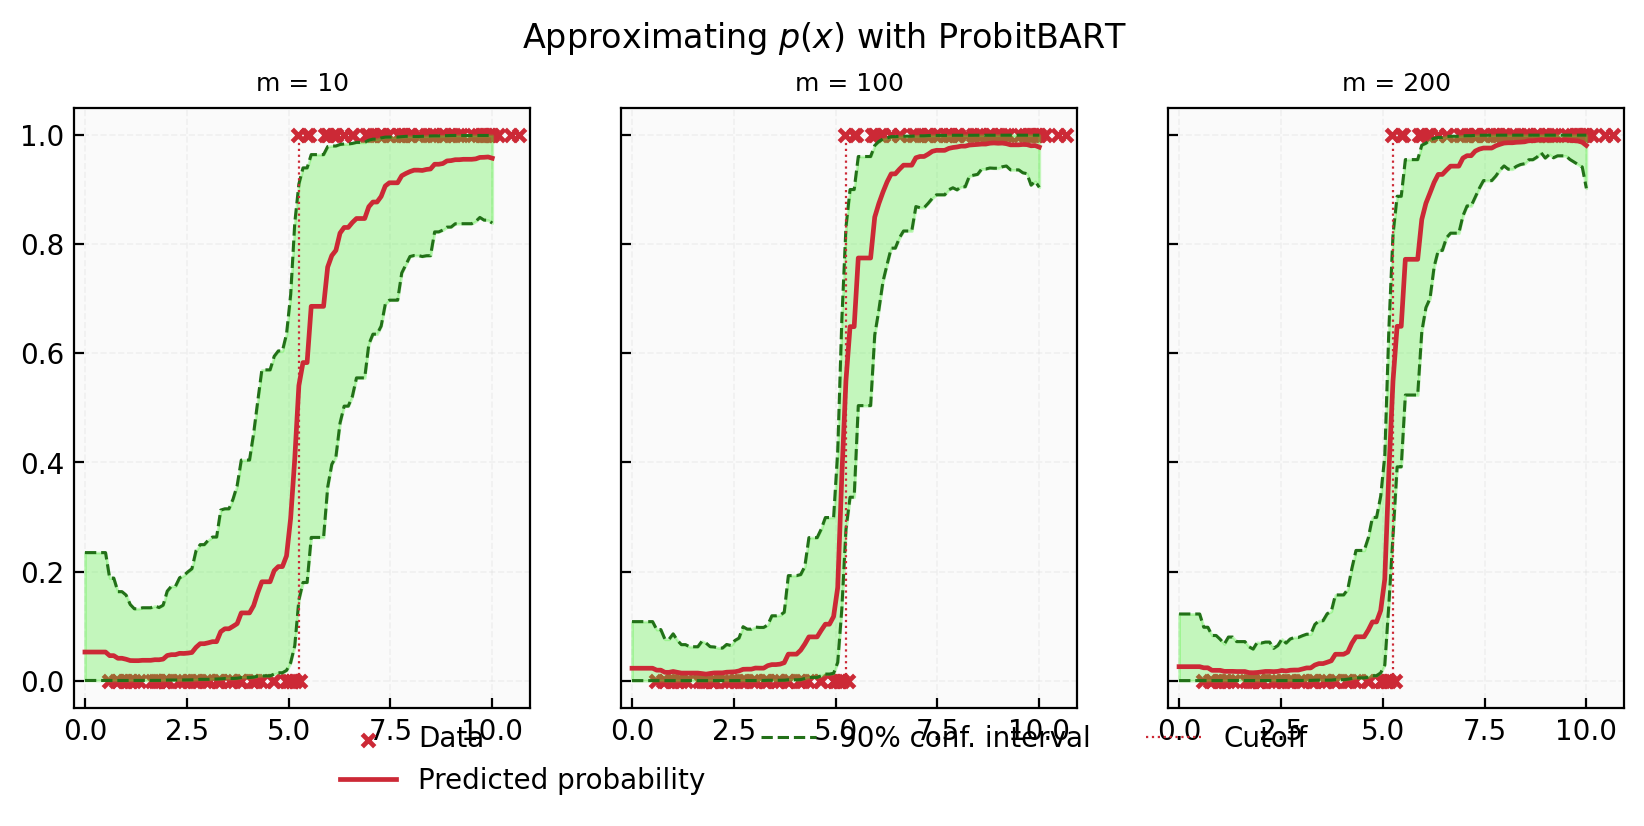

In [33]:
m = [10, 100, 200]
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharey=True, dpi=200)
for i in range(len(y_bart)):
    axes[i].scatter(x, y, marker='x', s=20.0, label=r"Data")
    axes[i].plot(x_true, y_bart[i], label="Predicted probability")
    axes[i].plot(x_true, conf_ints[i][0], ls='--', lw=1.1,  c=conf_color, label="90% conf. interval")
    axes[i].plot(x_true, conf_ints[i][1], ls='--', lw=1.1, c=conf_color)
    axes[i].fill_between(x_true, conf_ints[i][0], conf_ints[i][1], color=fill_color, alpha=0.3)
    axes[i].vlines(x_true[np.argmax(y_bart[i]>0.5)], 0, 1, ls=':', lw=0.8, label="Cutoff")
    axes[i].set_title(f"m = {m[i]}", fontsize=9)
    
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=3)

fig.suptitle("Approximating $p(x)$ with ProbitBART", fontsize=12)

plt.subplots_adjust(bottom=0.12)
plt.subplots_adjust(top=0.87)
plt.show()